# Exploración de Datos — Predicción del Precio de Vivienda
**Problema de Regresión: Valor de la Vivienda**  
Grupo 4 — Modelos Estadísticos

## 0. Instalación e importación de librerías

In [26]:
paquetes <- c("tidyverse", "ggplot2", "corrplot", "moments",
              "gridExtra", "scales", "knitr", "reshape2", "GGally")

nuevos <- paquetes[!(paquetes %in% installed.packages()[, "Package"])]
if (length(nuevos) > 0) install.packages(nuevos, quiet = TRUE)

# Cargar librerías
library(tidyverse)
library(ggplot2)
library(corrplot)
library(moments)    # skewness y kurtosis
library(gridExtra)
library(scales)
library(knitr)
library(reshape2)
library(GGally)

# Opciones globales
options(scipen = 999, digits = 3)
cat("Librerías cargadas correctamente\n")

Librerías cargadas correctamente


## 1. Exploración inicial y estructura de datos

In [27]:
# Carga directa
df <- read.csv("../data/raw/Train real state.csv", stringsAsFactors = TRUE)

# Eliminar columna índice si existe
df$X <- NULL

cat("Dimensiones del dataset:", nrow(df), "filas x", ncol(df), "columnas\n")
head(df)

Dimensiones del dataset: 4124 filas x 30 columnas


,SalePrice,YearBuilt,YrSold,MonthSold,Size.sqf.,Floor,HallwayType,HeatingType,AptManageType,N_Parkinglot.Ground.,⋯,N_FacilitiesNearBy.Mall.,N_FacilitiesNearBy.ETC.,N_FacilitiesNearBy.Park.,N_SchoolNearBy.Elementary.,N_SchoolNearBy.Middle.,N_SchoolNearBy.High.,N_SchoolNearBy.University.,N_FacilitiesInApt,N_FacilitiesNearBy.Total.,N_SchoolNearBy.Total.
,<int>,<int>,<int>,<int>,<int>,<int>,<fct>,<fct>,<fct>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,141592,2006,2007,8,814,3,terraced,individual_heating,management_in_trust,111,⋯,1,1,0,3,2,2,2,5,6,9
2,51327,1985,2007,8,587,8,corridor,individual_heating,self_management,80,⋯,1,2,1,2,1,1,0,3,12,4
3,48672,1985,2007,8,587,6,corridor,individual_heating,self_management,80,⋯,1,2,1,2,1,1,0,3,12,4
4,221238,1993,2007,8,1761,3,mixed,individual_heating,management_in_trust,523,⋯,1,5,0,4,3,5,5,4,14,17
5,78318,1992,2007,8,644,2,mixed,individual_heating,self_management,142,⋯,1,1,0,3,3,4,4,3,9,14
6,61946,1993,2007,8,644,10,mixed,individual_heating,management_in_trust,523,⋯,1,5,0,4,3,5,5,4,14,17


In [28]:
# Tipos de datos y estructura general
cat("=== ESTRUCTURA DEL DATASET ===\n")
str(df)

=== ESTRUCTURA DEL DATASET ===
'data.frame':	4124 obs. of  30 variables:
 $ SalePrice                         : int  141592 51327 48672 221238 78318 61946 83185 168141 153982 200884 ...
 $ YearBuilt                         : int  2006 1985 1985 1993 1992 1993 1992 1986 1986 2007 ...
 $ YrSold                            : int  2007 2007 2007 2007 2007 2007 2007 2007 2007 2007 ...
 $ MonthSold                         : int  8 8 8 8 8 8 8 8 8 8 ...
 $ Size.sqf.                         : int  814 587 587 1761 644 644 644 1377 914 868 ...
 $ Floor                             : int  3 8 6 3 2 10 13 4 11 18 ...
 $ HallwayType                       : Factor w/ 3 levels "corridor","mixed",..: 3 1 1 2 2 2 2 3 3 3 ...
 $ HeatingType                       : Factor w/ 2 levels "central_heating",..: 2 2 2 2 2 2 2 1 1 2 ...
 $ AptManageType                     : Factor w/ 2 levels "management_in_trust",..: 1 2 2 1 2 1 2 1 1 1 ...
 $ N_Parkinglot.Ground.              : int  111 80 80 523 142 523 142 7

In [29]:
# Identificar columnas categóricas y numéricas
cat_cols <- names(df)[sapply(df, is.factor)]
num_cols <- names(df)[sapply(df, is.numeric)]

# Remover el índice ('Unnamed..0' o 'X') y la variable objetivo para no tratarla como un predictor
num_cols_feat <- num_cols[!num_cols %in% c("SalePrice")]

cat("\nVariables categóricas (", length(cat_cols), "):\n")
print(cat_cols)

cat("\nVariables numéricas sin target (", length(num_cols_feat), "):\n")
print(num_cols_feat)


Variables categóricas ( 6 ):
[1] "HallwayType"   "HeatingType"   "AptManageType" "TimeToBusStop"
[5] "TimeToSubway"  "SubwayStation"

Variables numéricas sin target ( 23 ):
 [1] "YearBuilt"                          "YrSold"                            
 [3] "MonthSold"                          "Size.sqf."                         
 [5] "Floor"                              "N_Parkinglot.Ground."              
 [7] "N_Parkinglot.Basement."             "N_APT"                             
 [9] "N_manager"                          "N_elevators"                       
[11] "N_FacilitiesNearBy.PublicOffice."   "N_FacilitiesNearBy.Hospital."      
[13] "N_FacilitiesNearBy.Dpartmentstore." "N_FacilitiesNearBy.Mall."          
[15] "N_FacilitiesNearBy.ETC."            "N_FacilitiesNearBy.Park."          
[17] "N_SchoolNearBy.Elementary."         "N_SchoolNearBy.Middle."            
[19] "N_SchoolNearBy.High."               "N_SchoolNearBy.University."        
[21] "N_FacilitiesInApt"            

## 2. Calidad y Limpieza de datos

In [30]:
# === Valores faltantes y duplicados ===
missing_df <- data.frame(
  Variable    = names(df),
  Faltantes   = colSums(is.na(df)),
  Porcentaje  = round(colSums(is.na(df)) / nrow(df) * 100, 2)
)

missing_df <- missing_df[missing_df$Faltantes > 0, ]
missing_df <- missing_df[order(-missing_df$Porcentaje), ]

if (nrow(missing_df) == 0) {
  cat("No hay valores faltantes en el dataset\n")
} else {
  print(missing_df)
}

# === DUPLICADOS ===
n_dup <- sum(duplicated(df))
cat("Filas duplicadas exactas:", n_dup, "\n")

No hay valores faltantes en el dataset


Filas duplicadas exactas: 192 


In [31]:
# Ver los grupos de duplicados, ordenados para comparar pares
dup_view <- df[duplicated(df) | duplicated(df, fromLast = TRUE), ]
dup_view <- dup_view[order(dup_view$SalePrice, dup_view$Size.sqf., dup_view$Floor), ]
head(dup_view[, c("SalePrice","YearBuilt","Size.sqf.","Floor","SubwayStation")], 20)

,SalePrice,YearBuilt,Size.sqf.,Floor,SubwayStation
,<int>,<int>,<int>,<int>,<fct>
719,61946,1992,576,11,Myung-duk
724,61946,1992,576,11,Myung-duk
873,73053,2005,572,6,Bangoge
926,73053,2005,572,6,Bangoge
938,73442,2005,572,9,Bangoge
944,73442,2005,572,9,Bangoge
856,73840,2005,572,11,Bangoge
908,73840,2005,572,11,Bangoge
842,73840,2005,572,12,Bangoge


In [32]:
# Eliminar duplicados exactos
df <- df[!duplicated(df), ]

cat("Dimensiones tras eliminar duplicados:", nrow(df), "filas x", ncol(df), "columnas\n")

Dimensiones tras eliminar duplicados: 3932 filas x 30 columnas


## 3. Estadísticas descriptivas, distribución y outliers - Variables numericas

In [33]:
# Estadisticas descriptivas para variables numéricas
vars_num <- df[, c(num_cols_feat, "SalePrice")]

tabla_desc <- data.frame(
  COLUMNA = names(vars_num),
  CONTEO  = sapply(vars_num, function(x) sum(!is.na(x))),
  MEDIA   = round(sapply(vars_num, mean,   na.rm = TRUE), 2),
  MEDIANA = round(sapply(vars_num, median, na.rm = TRUE), 2),
  STD     = round(sapply(vars_num, sd,     na.rm = TRUE), 2),
  MIN     = sapply(vars_num, min, na.rm = TRUE),
  Q25     = sapply(vars_num, quantile, probs = 0.25, na.rm = TRUE),
  Q50     = sapply(vars_num, quantile, probs = 0.50, na.rm = TRUE),
  Q75     = sapply(vars_num, quantile, probs = 0.75, na.rm = TRUE),
  MAX     = sapply(vars_num, max, na.rm = TRUE),
  stringsAsFactors = FALSE
)
rownames(tabla_desc) <- NULL

# Mostrar en el notebook
library(knitr)
kable(tabla_desc, col.names = c("COLUMNA","CONTEO","MEDIA","MEDIANA","STD",
                                "MIN","25%","50%","75%","MAX"))





|COLUMNA                            | CONTEO|     MEDIA| MEDIANA|       STD|   MIN|    25%|    50%|    75%|    MAX|
|:----------------------------------|------:|---------:|-------:|---------:|-----:|------:|------:|------:|------:|
|YearBuilt                          |   3932|   2002.65|    2006|      8.89|  1978|   1993|   2006|   2007|   2015|
|YrSold                             |   3932|   2012.68|    2013|      2.89|  2007|   2010|   2013|   2015|   2017|
|MonthSold                          |   3932|      6.30|       6|      3.35|     1|      3|      6|      9|     12|
|Size.sqf.                          |   3932|    969.61|     910|    377.88|   135|    644|    910|   1160|   2337|
|Floor                              |   3932|     12.15|      11|      7.69|     1|      6|     11|     17|     43|
|N_Parkinglot.Ground.               |   3932|    201.48|     111|    219.85|     0|     25|    111|    249|    713|
|N_Parkinglot.Basement.             |   3932|    559.41|     536|    4

No id variables; using all as measure variables



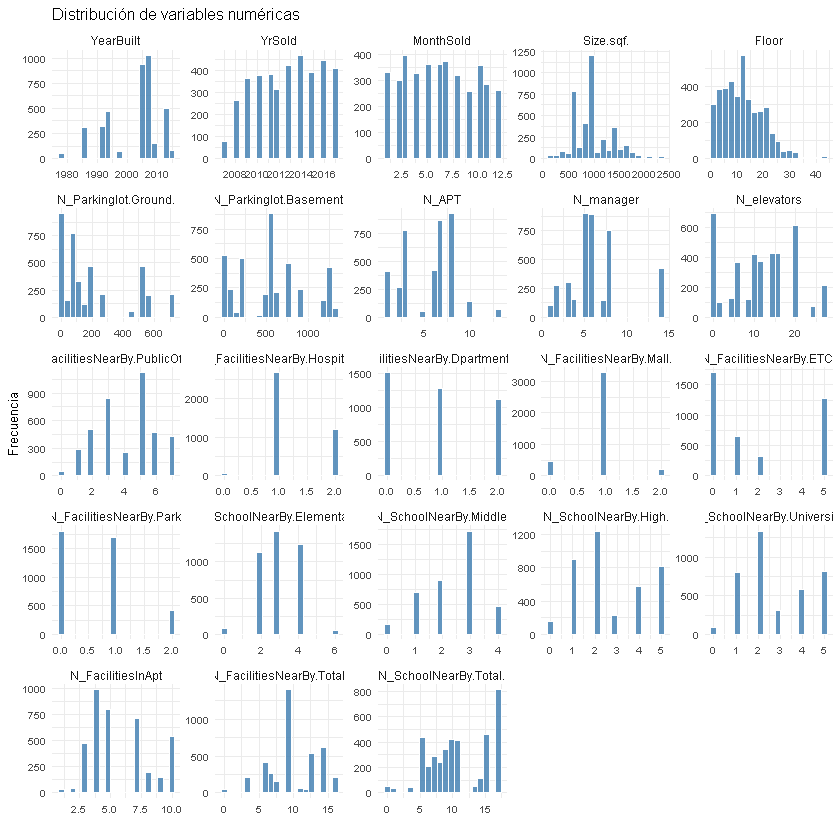

In [34]:
# Distribución de variables numéricas 
library(ggplot2)
library(reshape2)

# Convertir a formato largo para graficar todas juntas
df_long <- melt(df[, num_cols_feat])

ggplot(df_long, aes(x = value)) +
  geom_histogram(bins = 20, fill = "steelblue", color = "white", alpha = 0.85) +
  facet_wrap(~ variable, scales = "free", ncol = 5) +
  theme_minimal(base_size = 8) +
  labs(title = "Distribución de variables numéricas", x = "", y = "Frecuencia") +
  theme(strip.text = element_text(size = 7),
        axis.text = element_text(size = 6))
ggsave("distribucion_numericas.png", width = 14, height = 12, dpi = 150)

No id variables; using all as measure variables



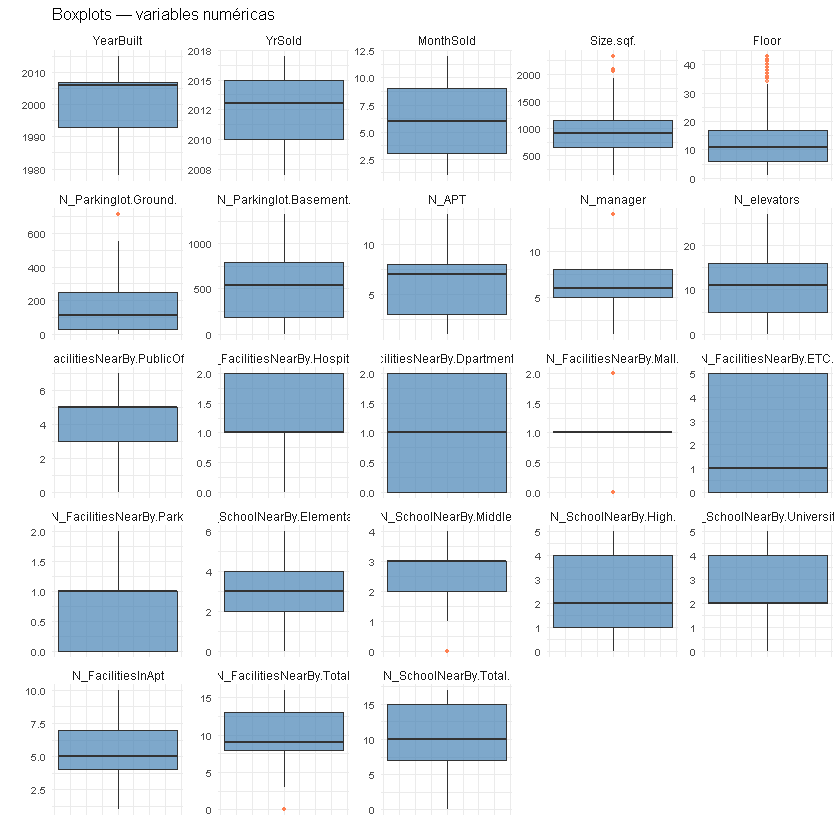

In [35]:
# Boxplots para detectar outliers
library(ggplot2)
library(reshape2)

df_long <- melt(df[, num_cols_feat])

ggplot(df_long, aes(y = value)) +
  geom_boxplot(fill = "steelblue", alpha = 0.7,
               outlier.color = "coral", outlier.size = 0.8) +
  facet_wrap(~ variable, scales = "free", ncol = 5) +
  theme_minimal(base_size = 8) +
  labs(title = "Boxplots — variables numéricas", x = "", y = "") +
  theme(strip.text = element_text(size = 7),
        axis.text.x = element_blank(),
        axis.ticks.x = element_blank(),
        axis.text.y = element_text(size = 6))
ggsave("boxplots_numericas.png", width = 14, height = 12, dpi = 150)

## 4. Estadísticas descriptivas y frecuencia - Variables categoricas

In [36]:
# Estadísticas descriptivas para variables categóricas
tabla_cat <- data.frame(
  COLUMNA    = cat_cols,
  CONTEO     = sapply(cat_cols, function(c) sum(!is.na(df[[c]]))),
  CATEGORIAS = sapply(cat_cols, function(c) nlevels(df[[c]])),
  TOP        = sapply(cat_cols, function(c) names(which.max(table(df[[c]])))),
  FRECUENCIA = sapply(cat_cols, function(c) max(table(df[[c]]))),
  PORCENTAJE = sapply(cat_cols, function(c) round(max(table(df[[c]])) / sum(!is.na(df[[c]])) * 100, 2))
)
rownames(tabla_cat) <- NULL

library(knitr)
kable(tabla_cat, align = "lrrlrr",
      col.names = c("COLUMNA","CONTEO","CATEGORÍAS","TOP","FRECUENCIA","% TOP"))

write.csv2(tabla_cat, "estadisticas_categoricas.csv", row.names = FALSE)




|COLUMNA       | CONTEO| CATEGORÍAS|TOP                   | FRECUENCIA| % TOP|
|:-------------|------:|----------:|:---------------------|----------:|-----:|
|HallwayType   |   3932|          3|terraced              |       2380|  60.5|
|HeatingType   |   3932|          2|individual_heating    |       3720|  94.6|
|AptManageType |   3932|          2|management_in_trust   |       3684|  93.7|
|TimeToBusStop |   3932|          3|0~5min                |       2977|  75.7|
|TimeToSubway  |   3932|          5|0-5min                |       1830|  46.5|
|SubwayStation |   3932|          8|Kyungbuk_uni_hospital |       1072|  27.3|

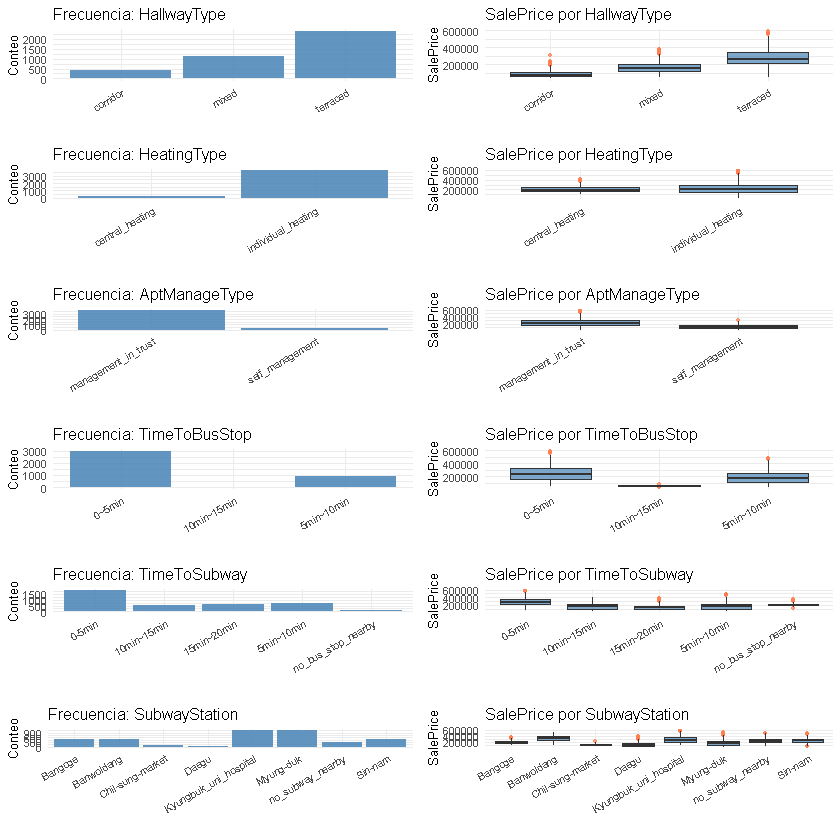

In [37]:
# Variables categóricas: frecuencia y boxplot de SalePrice
library(ggplot2)
library(gridExtra)

plots <- list()

for (col in cat_cols) {
  # Gráfico de frecuencia
  p1 <- ggplot(df, aes(x = .data[[col]])) +
    geom_bar(fill = "steelblue", alpha = 0.85) +
    theme_minimal(base_size = 8) +
    labs(title = paste("Frecuencia:", col), x = "", y = "Conteo") +
    theme(axis.text.x = element_text(angle = 30, hjust = 1, size = 6))

  # Boxplot SalePrice por categoría
  p2 <- ggplot(df, aes(x = .data[[col]], y = SalePrice)) +
    geom_boxplot(fill = "steelblue", alpha = 0.7,
                 outlier.color = "coral", outlier.size = 0.8) +
    theme_minimal(base_size = 8) +
    labs(title = paste("SalePrice por", col), x = "", y = "SalePrice") +
    theme(axis.text.x = element_text(angle = 30, hjust = 1, size = 6))

  plots[[length(plots) + 1]] <- p1
  plots[[length(plots) + 1]] <- p2
}

# Organizar en grilla (2 columnas: frecuencia + boxplot por fila)
grid.arrange(grobs = plots, ncol = 2)

g <- arrangeGrob(grobs = plots, ncol = 2)
ggsave("categoricas_frecuencia.png", g, width = 12, height = 18, dpi = 150)

## 5. Análisis de la variable objetivo: SalePrice

Media:     225857 
Mediana:   212389 
Skewness:  0.439 
Kurtosis:  2.68 


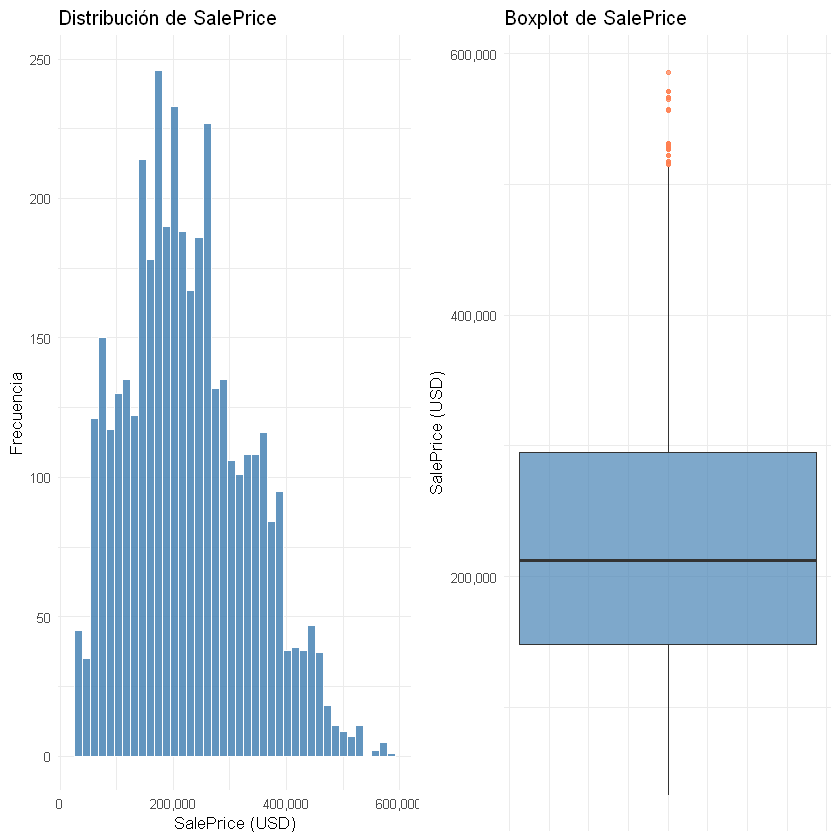

In [38]:
# === VARIABLE OBJETIVO: SALEPRICE ===
library(ggplot2)
library(gridExtra)
library(scales)

# Histograma
p1 <- ggplot(df, aes(x = SalePrice)) +
  geom_histogram(bins = 40, fill = "steelblue", color = "white", alpha = 0.85) +
  scale_x_continuous(labels = comma) +
  theme_minimal(base_size = 10) +
  labs(title = "Distribución de SalePrice", x = "SalePrice (USD)", y = "Frecuencia")

# Boxplot
p2 <- ggplot(df, aes(y = SalePrice)) +
  geom_boxplot(fill = "steelblue", alpha = 0.7,
               outlier.color = "coral", outlier.size = 1) +
  scale_y_continuous(labels = comma) +
  theme_minimal(base_size = 10) +
  labs(title = "Boxplot de SalePrice", y = "SalePrice (USD)") +
  theme(axis.text.x = element_blank(), axis.ticks.x = element_blank())

grid.arrange(p1, p2, ncol = 2)

# Estadísticas de forma
library(moments)
cat("Media:    ", round(mean(df$SalePrice), 2), "\n")
cat("Mediana:  ", round(median(df$SalePrice), 2), "\n")
cat("Skewness: ", round(skewness(df$SalePrice), 3), "\n")
cat("Kurtosis: ", round(kurtosis(df$SalePrice), 3), "\n")

g <- arrangeGrob(p1, p2, ncol = 2)
ggsave("variable_objetivo.png", g, width = 14, height = 5, dpi = 150)

## 6. Correlación entre variables numéricas

agg_record_5f2c1c7a502d 
                      2

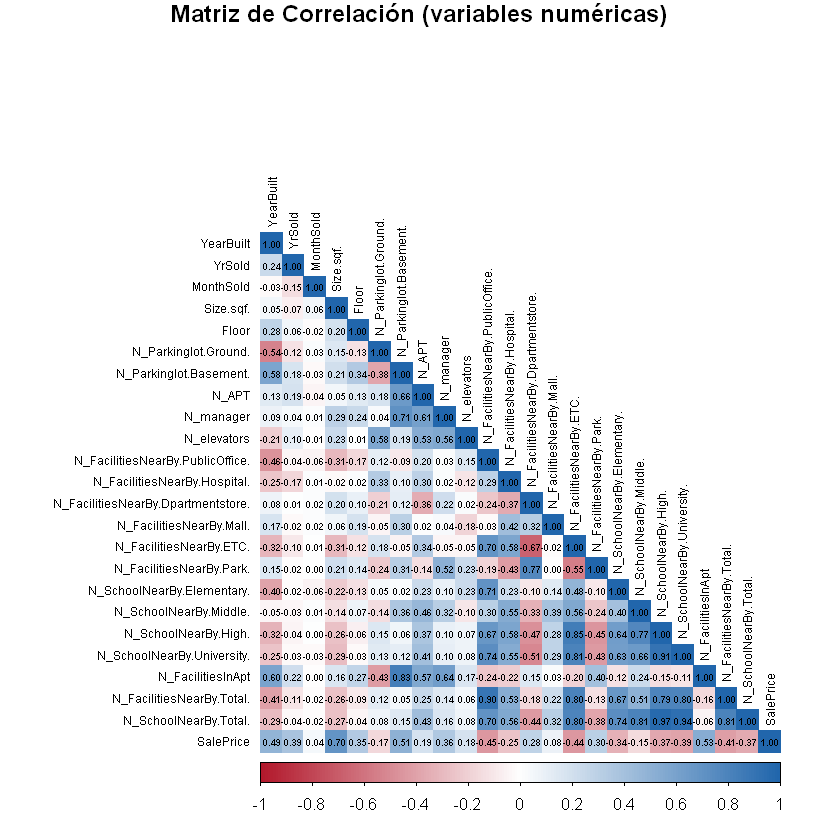

In [39]:
# === MATRIZ DE CORRELACIÓN (VARIABLES NUMÉRICAS) ===
library(corrplot)

# Calcular correlaciones (predictores + target)
corr_matrix <- cor(df[, c(num_cols_feat, "SalePrice")])

# Visualización
corrplot(corr_matrix, method = "color", type = "lower",
         tl.cex = 0.6, tl.col = "black",
         number.cex = 0.45, addCoef.col = "black",
         col = colorRampPalette(c("#B2182B", "white", "#2166AC"))(200),
         title = "Matriz de Correlación (variables numéricas)",
         mar = c(0,0,1,0))

png("matriz_correlacion.png", width = 1600, height = 1400, res = 130)
corrplot(corr_matrix, method = "color", type = "lower",
         tl.cex = 0.6, tl.col = "black",
         number.cex = 0.45, addCoef.col = "black",
         col = colorRampPalette(c("#B2182B", "white", "#2166AC"))(200),
         mar = c(0,0,1,0))
dev.off()

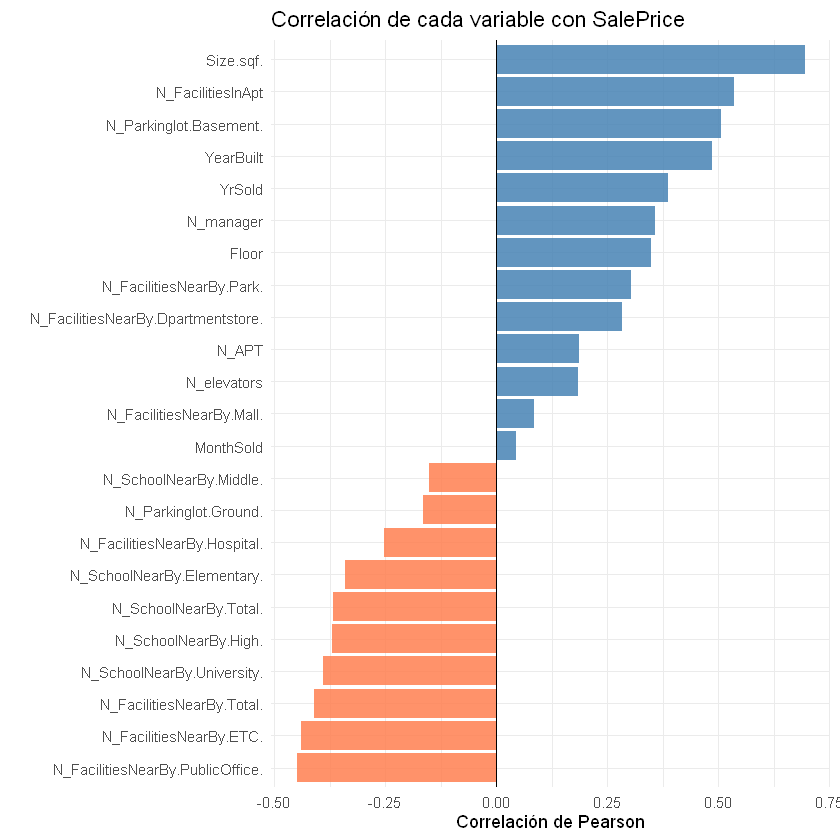

In [40]:
# Top correlaciones con SalePrice (ordenadas por valor absoluto)
corr_target <- corr_matrix["SalePrice", ]
corr_target <- corr_target[names(corr_target) != "SalePrice"]
corr_target <- sort(corr_target, decreasing = FALSE)  # ascendente para barh

corr_df <- data.frame(
  Variable    = names(corr_target),
  Correlacion = as.numeric(corr_target)
)
corr_df$Color <- ifelse(corr_df$Correlacion >= 0, "positiva", "negativa")

ggplot(corr_df, aes(x = Correlacion,
                    y = reorder(Variable, Correlacion),
                    fill = Color)) +
  geom_bar(stat = "identity", alpha = 0.85) +
  geom_vline(xintercept = 0, color = "black", linewidth = 0.5) +
  scale_fill_manual(values = c("positiva" = "steelblue",
                               "negativa" = "coral")) +
  labs(title = "Correlación de cada variable con SalePrice",
       x = "Correlación de Pearson", y = "") +
  theme_minimal() +
  theme(legend.position = "none")

## 7. Scatter plots — variables más correlacionadas con SalePrice

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


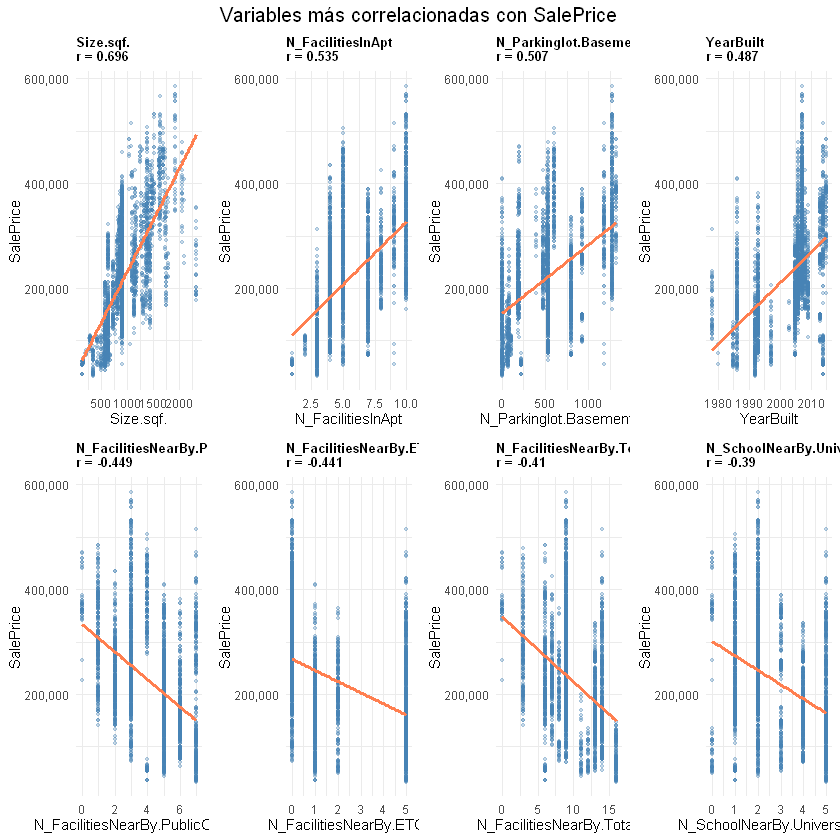

In [41]:
# Top 8 variables con mayor correlación absoluta
top8 <- names(sort(abs(corr_target), decreasing = TRUE))[1:8]

plots_scatter <- lapply(top8, function(col) {
  r_val <- round(cor(df[[col]], df$SalePrice, use = "complete.obs"), 3)
  ggplot(df, aes_string(x = col, y = "SalePrice")) +
    geom_point(alpha = 0.3, color = "steelblue", size = 0.8) +
    geom_smooth(method = "lm", se = FALSE, color = "coral", linewidth = 1) +
    scale_y_continuous(labels = comma) +
    labs(title = paste0(col, "\nr = ", r_val),
         x = col, y = "SalePrice") +
    theme_minimal(base_size = 9) +
    theme(plot.title = element_text(size = 8, face = "bold"))
})

do.call(grid.arrange, c(plots_scatter, ncol = 4,
  top = "Variables más correlacionadas con SalePrice"))

## 8. Resumen final de la exploración

In [42]:
cat(strrep("=", 60), "\n")
cat("         RESUMEN DE LA EXPLORACIÓN DE DATOS\n")
cat(strrep("=", 60), "\n")
cat(sprintf("  Observaciones:            %d\n",   nrow(df)))
cat(sprintf("  Variables totales:        %d\n",   ncol(df)))
cat(sprintf("  Variables numéricas:      %d\n",   length(num_cols_feat)))
cat(sprintf("  Variables categóricas:    %d\n",   length(cat_cols)))
cat(sprintf("  Columnas con nulos:       %d\n",   sum(colSums(is.na(df)) > 0)))
cat(sprintf("  SalePrice — Media:        $%s\n",  format(round(mean(df$SalePrice), 0), big.mark=",")))
cat(sprintf("  SalePrice — Mediana:      $%s\n",  format(median(df$SalePrice), big.mark=",")))
cat(sprintf("  SalePrice — Std:          $%s\n",  format(round(sd(df$SalePrice), 0), big.mark=",")))
cat(sprintf("  SalePrice — Min:          $%s\n",  format(min(df$SalePrice), big.mark=",")))
cat(sprintf("  SalePrice — Max:          $%s\n",  format(max(df$SalePrice), big.mark=",")))
cat(sprintf("  Asimetría SalePrice:      %.4f\n", skewness(df$SalePrice)))
cat("\n  Top 5 correlaciones con SalePrice:\n")
top5_corr <- sort(abs(corr_target), decreasing = TRUE)[1:5]
for (nm in names(top5_corr)) {
  cat(sprintf("    %-35s r = %.4f\n", nm, corr_matrix["SalePrice", nm]))
}
cat(strrep("=", 60), "\n")

         RESUMEN DE LA EXPLORACIÓN DE DATOS
  Observaciones:            3932
  Variables totales:        30
  Variables numéricas:      23
  Variables categóricas:    6
  Columnas con nulos:       0
  SalePrice — Media:        $225,857
  SalePrice — Mediana:      $212,389
  SalePrice — Std:          $106,273
  SalePrice — Min:          $32,743
  SalePrice — Max:          $585,840
  Asimetría SalePrice:      0.4391

  Top 5 correlaciones con SalePrice:
    Size.sqf.                           r = 0.6955
    N_FacilitiesInApt                   r = 0.5349
    N_Parkinglot.Basement.              r = 0.5065
    YearBuilt                           r = 0.4870
    N_FacilitiesNearBy.PublicOffice.    r = -0.4494


# Modelo — Predicción del Precio de Vivienda
**Modelo de regresión lineal**
**Problema de Regresión: Valor de la Vivienda**  

## 0. Preparación de datos

In [43]:
library(dplyr)

# Cargar train y test
train <- read.csv("../data/raw/Train real state.csv", stringsAsFactors = TRUE)
test  <- read.csv("../data/raw/Test real state.csv",  stringsAsFactors = TRUE)

# La primera columna sin nombre llega como "X":
# en train es un índice desechable, en test es el Id que exige Kaggle
test_ids <- test$X
train$X <- NULL
test$X  <- NULL

# Alinear niveles de factores del test a los de train (evita errores en predict)
cat_cols <- c("HallwayType","HeatingType","AptManageType",
              "TimeToBusStop","TimeToSubway","SubwayStation")
for (c in cat_cols)
  test[[c]] <- factor(as.character(test[[c]]), levels = levels(train[[c]]))

# Quitar duplicados exactos SOLO en train
train <- train[!duplicated(train), ]

cat("train:", nrow(train), "x", ncol(train), "\n")
cat("test :", nrow(test), "x", ncol(test), " | n Ids:", length(test_ids), "\n")

train: 3932 x 30 
test : 1767 x 29  | n Ids: 1767 


## 1. Selección de variables — colinealidad y redundancia

In [44]:
# 1a. Verificar si los "totales" son la suma exacta de sus componentes
fac_comp <- c("N_FacilitiesNearBy.PublicOffice.","N_FacilitiesNearBy.Hospital.",
              "N_FacilitiesNearBy.Dpartmentstore.","N_FacilitiesNearBy.Mall.",
              "N_FacilitiesNearBy.ETC.","N_FacilitiesNearBy.Park.")
sch_comp <- c("N_SchoolNearBy.Elementary.","N_SchoolNearBy.Middle.",
              "N_SchoolNearBy.High.","N_SchoolNearBy.University.")

es_suma_facilities <- all(train$N_FacilitiesNearBy.Total. == rowSums(train[fac_comp]))
es_suma_schools     <- all(train$N_SchoolNearBy.Total.     == rowSums(train[sch_comp]))

cat("N_FacilitiesNearBy.Total. es la suma exacta de sus componentes:", es_suma_facilities, "\n")
cat("N_SchoolNearBy.Total. es la suma exacta de sus componentes:    ", es_suma_schools, "\n")

N_FacilitiesNearBy.Total. es la suma exacta de sus componentes: TRUE 
N_SchoolNearBy.Total. es la suma exacta de sus componentes:     TRUE 


In [45]:
install.packages("car")

Warning message:
"package 'car' is in use and will not be installed"


In [47]:
alias(modelo_con_totales)

Model :
SalePrice ~ YearBuilt + YrSold + MonthSold + Size.sqf. + Floor + 
    HallwayType + HeatingType + AptManageType + N_Parkinglot.Ground. + 
    N_Parkinglot.Basement. + TimeToBusStop + TimeToSubway + N_APT + 
    N_manager + N_elevators + SubwayStation + N_FacilitiesNearBy.PublicOffice. + 
    N_FacilitiesNearBy.Hospital. + N_FacilitiesNearBy.Dpartmentstore. + 
    N_FacilitiesNearBy.Mall. + N_FacilitiesNearBy.ETC. + N_FacilitiesNearBy.Park. + 
    N_SchoolNearBy.Elementary. + N_SchoolNearBy.Middle. + N_SchoolNearBy.High. + 
    N_SchoolNearBy.University. + N_FacilitiesInApt + N_FacilitiesNearBy.Total. + 
    N_SchoolNearBy.Total.

Complete :
                                   (Intercept)           YearBuilt            
SubwayStationSin-nam                                   1                     0
N_FacilitiesNearBy.Dpartmentstore.           -7805/15886                     0
N_FacilitiesNearBy.Mall.                    -22993/43856                     0
N_FacilitiesNearBy.ETC.    

In [49]:
alias(modelo_base)

Model :
SalePrice ~ YearBuilt + YrSold + MonthSold + Size.sqf. + Floor + 
    HallwayType + HeatingType + AptManageType + N_Parkinglot.Ground. + 
    N_Parkinglot.Basement. + TimeToBusStop + TimeToSubway + N_APT + 
    N_manager + N_elevators + N_FacilitiesNearBy.PublicOffice. + 
    N_FacilitiesNearBy.Hospital. + N_FacilitiesNearBy.Dpartmentstore. + 
    N_FacilitiesNearBy.Mall. + N_FacilitiesNearBy.ETC. + N_FacilitiesNearBy.Park. + 
    N_SchoolNearBy.Elementary. + N_SchoolNearBy.Middle. + N_SchoolNearBy.High. + 
    N_SchoolNearBy.University. + N_FacilitiesInApt

Complete :
                           (Intercept)          YearBuilt           
N_SchoolNearBy.High.               -68649/82571                    0
N_SchoolNearBy.University.      -3716610/657223                    0
N_FacilitiesInApt              -10180691/198513                    0
                           YrSold               MonthSold           
N_SchoolNearBy.High.                          0                    0
N_

In [50]:
# Quitar también las 3 variables que resultaron aliased (combinación lineal exacta
# de las demás, probablemente por redundancia entre colegios cercanos y ubicación)
train_m <- train_m %>% select(-N_SchoolNearBy.High., -N_SchoolNearBy.University., -N_FacilitiesInApt)

modelo_base <- lm(SalePrice ~ ., data = train_m)
vif(modelo_base)

,GVIF,Df,GVIF^(1/(2*Df))
YearBuilt,86.10,1,9.28
YrSold,1.32,1,1.15
MonthSold,1.06,1,1.03
Size.sqf.,2.05,1,1.43
Floor,1.22,1,1.11
HallwayType,865019.09,2,30.50
HeatingType,3943.20,1,62.79
AptManageType,89.81,1,9.48
N_Parkinglot.Ground.,29744.59,1,172.47
N_Parkinglot.Basement.,307045.15,1,554.12


In [51]:
library(MASS)

# Selección stepwise bidireccional por AIC, partiendo del modelo completo (sin aliasing)
modelo_step <- stepAIC(modelo_base, direction = "both", trace = FALSE)

# Ver qué variables sobrevivieron
summary(modelo_step)


Adjuntando el paquete: 'MASS'


The following object is masked from 'package:dplyr':

    select





Call:
lm(formula = SalePrice ~ YearBuilt + YrSold + MonthSold + Size.sqf. + 
    Floor + HallwayType + HeatingType + AptManageType + N_Parkinglot.Ground. + 
    N_Parkinglot.Basement. + TimeToBusStop + TimeToSubway + N_APT + 
    N_manager + N_elevators + N_FacilitiesNearBy.PublicOffice. + 
    N_FacilitiesNearBy.Hospital. + N_FacilitiesNearBy.Dpartmentstore. + 
    N_FacilitiesNearBy.Mall. + N_FacilitiesNearBy.ETC. + N_FacilitiesNearBy.Park. + 
    N_SchoolNearBy.Elementary. + N_SchoolNearBy.Middle., data = train_m)

Residuals:
    Min      1Q  Median      3Q     Max 
-152788  -17312     625   19153  164122 

Coefficients:
                                      Estimate  Std. Error t value
(Intercept)                        -31703956.9    930639.7  -34.07
YearBuilt                               5052.8       577.8    8.74
YrSold                                 12827.5       220.3   58.23
MonthSold                               1762.5       170.1   10.36
Size.sqf.                       

In [52]:
# Verificar colinealidad del modelo ya seleccionado
vif(modelo_step)

,GVIF,Df,GVIF^(1/(2*Df))
YearBuilt,86.10,1,9.28
YrSold,1.32,1,1.15
MonthSold,1.06,1,1.03
Size.sqf.,2.05,1,1.43
Floor,1.22,1,1.11
HallwayType,865019.09,2,30.50
HeatingType,3943.20,1,62.79
AptManageType,89.81,1,9.48
N_Parkinglot.Ground.,29744.59,1,172.47
N_Parkinglot.Basement.,307045.15,1,554.12


In [53]:
# Eliminación iterativa por VIF: en cada paso quita la variable más colineal
# y recalcula, hasta que todo quede por debajo del umbral
vif_step <- function(model, threshold = 10) {
  repeat {
    v <- vif(model)
    if (is.matrix(v)) {
      # Para factores, VIF equivalente = GVIF^(1/(2*Df))^2
      vals <- v[, 3]^2
      names(vals) <- rownames(v)
    } else {
      vals <- v
    }
    max_val <- max(vals)
    if (max_val < threshold) break
    remove_var <- names(vals)[which.max(vals)]
    cat("Eliminando:", remove_var, "  (VIF =", round(max_val, 1), ")\n")
    model <- update(model, as.formula(paste(". ~ . -", remove_var)))
  }
  model
}

modelo_vif <- vif_step(modelo_base, threshold = 10)

Eliminando: N_Parkinglot.Basement.   (VIF = 307045 )
Eliminando: N_manager   (VIF = 368 )
Eliminando: N_elevators   (VIF = 155 )
Eliminando: N_FacilitiesNearBy.Dpartmentstore.   (VIF = 56.7 )
Eliminando: HeatingType   (VIF = 24.7 )
Eliminando: N_FacilitiesNearBy.ETC.   (VIF = 17.6 )
Eliminando: YearBuilt   (VIF = 13.8 )


In [54]:
summary(modelo_vif)
vif(modelo_vif)


Call:
lm(formula = SalePrice ~ YrSold + MonthSold + Size.sqf. + Floor + 
    HallwayType + AptManageType + N_Parkinglot.Ground. + TimeToBusStop + 
    TimeToSubway + N_APT + N_FacilitiesNearBy.PublicOffice. + 
    N_FacilitiesNearBy.Hospital. + N_FacilitiesNearBy.Mall. + 
    N_FacilitiesNearBy.Park. + N_SchoolNearBy.Elementary. + N_SchoolNearBy.Middle., 
    data = train_m)

Residuals:
    Min      1Q  Median      3Q     Max 
-218679  -20051    1569   23728  160398 

Coefficients:
                                     Estimate   Std. Error t value
(Intercept)                      -26046804.53    477999.57  -54.49
YrSold                               12978.83       237.34   54.68
MonthSold                             2139.67       187.68   11.40
Size.sqf.                              150.97         2.15   70.35
Floor                                 1369.79        88.37   15.50
HallwayTypemixed                    -25332.59      5512.33   -4.60
HallwayTypeterraced                  61513.

,GVIF,Df,GVIF^(1/(2*Df))
YrSold,1.24,1,1.11
MonthSold,1.04,1,1.02
Size.sqf.,1.73,1,1.31
Floor,1.21,1,1.10
HallwayType,70.99,2,2.90
AptManageType,1.96,1,1.40
N_Parkinglot.Ground.,4.28,1,2.07
TimeToBusStop,5.49,2,1.53
TimeToSubway,319.69,4,2.06
N_APT,4.07,1,2.02


In [55]:
# Prueba F parcial: ¿aportan las variables no significativas, en conjunto?
modelo_reducido <- update(modelo_vif, . ~ . - N_FacilitiesNearBy.Mall. 
                                          - N_FacilitiesNearBy.Park. 
                                          - N_SchoolNearBy.Middle.)

anova(modelo_reducido, modelo_vif)

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,3913,5851293282950,NA,NA,NA,NA
2,3910,5847856820321,3,3436462629,0.766,0.513


In [56]:
summary(modelo_reducido)
vif(modelo_reducido)


Call:
lm(formula = SalePrice ~ YrSold + MonthSold + Size.sqf. + Floor + 
    HallwayType + AptManageType + N_Parkinglot.Ground. + TimeToBusStop + 
    TimeToSubway + N_APT + N_FacilitiesNearBy.PublicOffice. + 
    N_FacilitiesNearBy.Hospital. + N_SchoolNearBy.Elementary., 
    data = train_m)

Residuals:
    Min      1Q  Median      3Q     Max 
-217711  -20201    1609   23332  160377 

Coefficients:
                                     Estimate   Std. Error t value
(Intercept)                      -26152583.02    471887.02  -55.42
YrSold                               13029.80       234.42   55.58
MonthSold                             2133.80       187.40   11.39
Size.sqf.                              150.68         2.12   71.18
Floor                                 1354.81        86.85   15.60
HallwayTypemixed                    -24211.64      4477.81   -5.41
HallwayTypeterraced                  63595.41      3641.81   17.46
AptManageTypeself_management        -46933.93      3369.43  

,GVIF,Df,GVIF^(1/(2*Df))
YrSold,1.21,1,1.10
MonthSold,1.04,1,1.02
Size.sqf.,1.68,1,1.30
Floor,1.17,1,1.08
HallwayType,33.11,2,2.40
AptManageType,1.76,1,1.33
N_Parkinglot.Ground.,3.49,1,1.87
TimeToBusStop,2.98,2,1.31
TimeToSubway,63.40,4,1.68
N_APT,2.29,1,1.51


## 2. Estructura del modelo

In [57]:
modelo_base <- modelo_reducido   # este es nuestro modelo de trabajo desde ahora

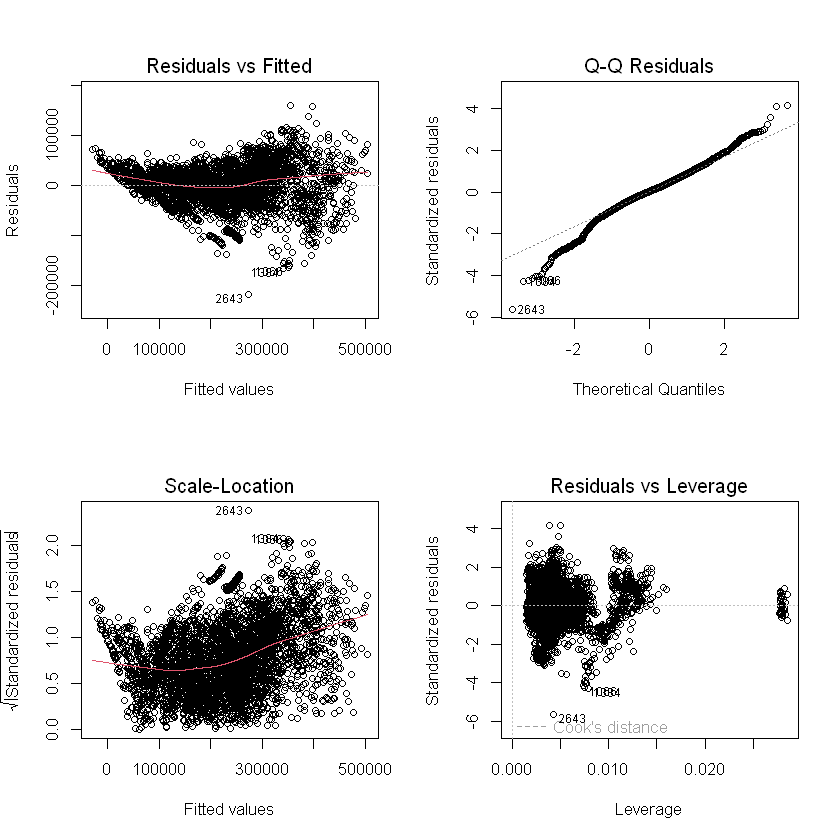

In [58]:
par(mfrow = c(2, 2))
plot(modelo_base)

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


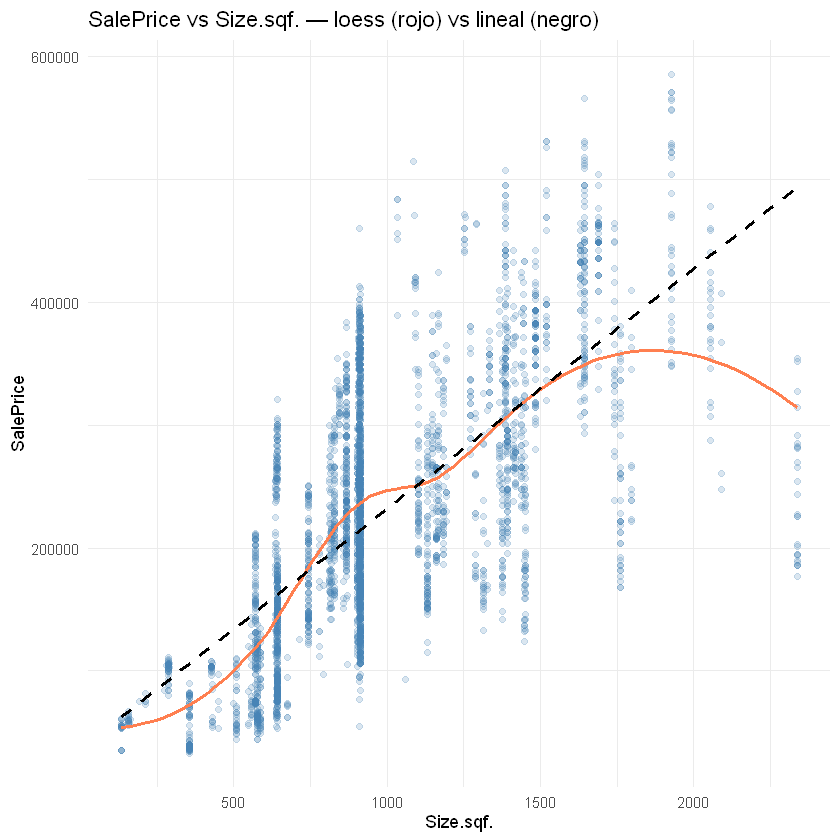

In [59]:
# Relación Size.sqf. vs SalePrice con curva suavizada (detectar curvatura)
library(ggplot2)
ggplot(train_m, aes(x = Size.sqf., y = SalePrice)) +
  geom_point(alpha = 0.2, color = "steelblue") +
  geom_smooth(method = "loess", color = "coral", se = FALSE) +
  geom_smooth(method = "lm", color = "black", se = FALSE, linetype = "dashed") +
  theme_minimal() +
  labs(title = "SalePrice vs Size.sqf. — loess (rojo) vs lineal (negro)")

In [60]:
# Inspeccionar la observación más influyente en los residuos
train_m[2643, ]

,SalePrice,YearBuilt,YrSold,MonthSold,Size.sqf.,Floor,HallwayType,HeatingType,AptManageType,N_Parkinglot.Ground.,⋯,N_manager,N_elevators,N_FacilitiesNearBy.PublicOffice.,N_FacilitiesNearBy.Hospital.,N_FacilitiesNearBy.Dpartmentstore.,N_FacilitiesNearBy.Mall.,N_FacilitiesNearBy.ETC.,N_FacilitiesNearBy.Park.,N_SchoolNearBy.Elementary.,N_SchoolNearBy.Middle.
,<int>,<int>,<int>,<int>,<int>,<int>,<fct>,<fct>,<fct>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
2736,308849,2007,2014,11,868,26,terraced,individual_heating,management_in_trust,0,⋯,14,16,3,1,2,1,0,2,3,3


In [61]:
# Ver también las otras dos que se repiten en los diagnósticos
train_m[c(864, 1086), ]

,SalePrice,YearBuilt,YrSold,MonthSold,Size.sqf.,Floor,HallwayType,HeatingType,AptManageType,N_Parkinglot.Ground.,⋯,N_manager,N_elevators,N_FacilitiesNearBy.PublicOffice.,N_FacilitiesNearBy.Hospital.,N_FacilitiesNearBy.Dpartmentstore.,N_FacilitiesNearBy.Mall.,N_FacilitiesNearBy.ETC.,N_FacilitiesNearBy.Park.,N_SchoolNearBy.Elementary.,N_SchoolNearBy.Middle.
,<int>,<int>,<int>,<int>,<int>,<int>,<fct>,<fct>,<fct>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
941,141592,2005,2010,5,743,19,mixed,individual_heating,management_in_trust,67,⋯,6,0,5,2,0,1,5,0,3,4
1170,206194,2007,2010,12,868,12,terraced,individual_heating,management_in_trust,0,⋯,14,16,3,1,2,1,0,2,3,3


In [62]:
# Probar estructura: agregar curvatura en Size.sqf.
modelo_cuad <- update(modelo_base, . ~ . + I(Size.sqf.^2))
summary(modelo_cuad)


Call:
lm(formula = SalePrice ~ YrSold + MonthSold + Size.sqf. + Floor + 
    HallwayType + AptManageType + N_Parkinglot.Ground. + TimeToBusStop + 
    TimeToSubway + N_APT + N_FacilitiesNearBy.PublicOffice. + 
    N_FacilitiesNearBy.Hospital. + N_SchoolNearBy.Elementary. + 
    I(Size.sqf.^2), data = train_m)

Residuals:
    Min      1Q  Median      3Q     Max 
-222323  -22060    -380   22320  193906 

Coefficients:
                                        Estimate      Std. Error t value
(Intercept)                      -27091626.30189    438288.95521  -61.81
YrSold                               13455.36962       217.60368   61.83
MonthSold                             1938.10531       173.61352   11.16
Size.sqf.                              384.51657         9.33842   41.18
Floor                                 1292.76818        80.42010   16.08
HallwayTypemixed                    -59621.26951      4368.96454  -13.65
HallwayTypeterraced                  26267.23674      3672.29697    

In [63]:
# Interacción: ¿el efecto de Size.sqf. depende del tipo de pasillo?
modelo_inter <- update(modelo_cuad, . ~ . + Size.sqf.:HallwayType)
summary(modelo_inter)


Call:
lm(formula = SalePrice ~ YrSold + MonthSold + Size.sqf. + Floor + 
    HallwayType + AptManageType + N_Parkinglot.Ground. + TimeToBusStop + 
    TimeToSubway + N_APT + N_FacilitiesNearBy.PublicOffice. + 
    N_FacilitiesNearBy.Hospital. + N_SchoolNearBy.Elementary. + 
    I(Size.sqf.^2) + Size.sqf.:HallwayType, data = train_m)

Residuals:
    Min      1Q  Median      3Q     Max 
-222535  -19705     644   20796  171778 

Coefficients:
                                        Estimate      Std. Error t value
(Intercept)                      -27685186.00818    420159.29353  -65.89
YrSold                               13751.89776       208.66970   65.90
MonthSold                             1776.82087       166.17804   10.69
Size.sqf.                              344.24445        11.66213   29.52
Floor                                 1200.67402        77.16333   15.56
HallwayTypemixed                    -57827.08708      7952.73576   -7.27
HallwayTypeterraced                 -36396.3

In [64]:
# Comparar formalmente los 3 modelos anidados con prueba F
anova(modelo_base, modelo_cuad, modelo_inter)

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,3913,5851293282950,NA,NA,NA,NA
2,3912,5011129584015,1,840163698936,718,0.000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000229
3,3910,4574852491711,2,436277092303,186,0.000000000000000000000000000000000000000000000000000000000000000000000000000004603185409667999585837938614218955990509130060672760009765625000000000


In [65]:
# Verificar formalmente las observaciones influyentes con Cook's distance
cooks <- cooks.distance(modelo_inter)
umbral <- 4 / nrow(train_m)
influyentes <- which(cooks > umbral)
cat("N° de observaciones influyentes (Cook's D > 4/n):", length(influyentes), "de", nrow(train_m), "\n")
cat("Las 5 más influyentes:\n")
print(sort(cooks, decreasing = TRUE)[1:5])

N° de observaciones influyentes (Cook's D > 4/n): 206 de 3932 
Las 5 más influyentes:
    331    2643     105    3016    4124 
0.00899 0.00838 0.00784 0.00766 0.00700 


## 3. Estimación de los parametros del modelo

In [66]:
modelo_final <- modelo_inter   # este es el modelo definitivo desde ahora

## 4. Verificación de los supuestos del modelo

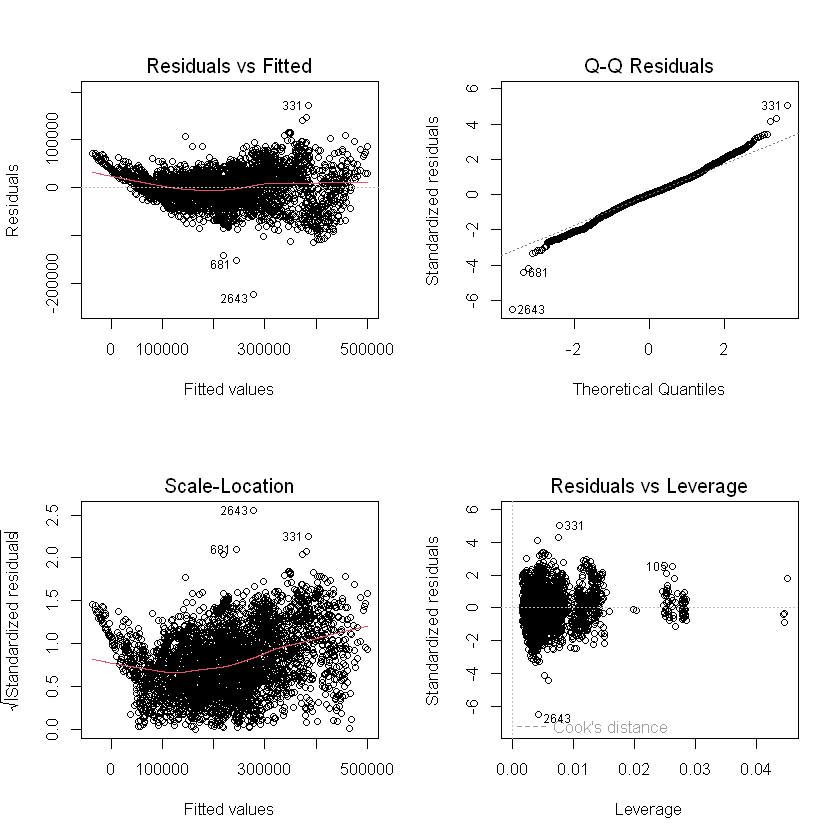

In [67]:
par(mfrow = c(2, 2))
plot(modelo_final)

In [68]:
library(lmtest)

# 1. Linealidad + homocedasticidad: Breusch-Pagan
bptest(modelo_final)

Warning message:
"package 'lmtest' was built under R version 4.6.1"
Cargando paquete requerido: zoo



Warning message:
"package 'zoo' was built under R version 4.6.1"

Adjuntando el paquete: 'zoo'


The following objects are masked from 'package:base':

    as.Date, as.Date.numeric





	studentized Breusch-Pagan test

data:  modelo_final
BP = 669, df = 21, p-value <0.0000000000000002


In [70]:
# 2. Normalidad de los residuos (Shapiro sobre una muestra, ya que n>5000 lo satura)
set.seed(42)
muestra <- sample(residuals(modelo_final), 5000)
shapiro.test(muestra)

ERROR: Error in sample.int(length(x), size, replace, prob): imposible tomar una muestra mayor que la población cuando 'replace = FALSE'


In [71]:
# 3. Independencia de los residuos (Durbin-Watson)
dwtest(modelo_final)


	Durbin-Watson test

data:  modelo_final
DW = 1, p-value <0.0000000000000002
alternative hypothesis: true autocorrelation is greater than 0


In [72]:
# Normalidad: usamos todos los residuos directamente (n=3932 < límite de 5000 de shapiro.test)
shapiro.test(residuals(modelo_final))


	Shapiro-Wilk normality test

data:  residuals(modelo_final)
W = 1, p-value = 0.00000000000001


In [73]:
# ¿El DW detecta estructura por edificio/ubicación en vez de autocorrelación temporal real?
# Ordenamos por N_APT y N_Parkinglot.Ground. (proxies de "mismo edificio") y repetimos
train_ordenado <- train_m[order(train_m$N_APT, train_m$N_Parkinglot.Ground.), ]
modelo_ordenado <- lm(formula(modelo_final), data = train_ordenado)
dwtest(modelo_ordenado)


	Durbin-Watson test

data:  modelo_ordenado
DW = 0.7, p-value <0.0000000000000002
alternative hypothesis: true autocorrelation is greater than 0


## 5. Determinación de la bondad de ajuste del modelo

In [74]:
# Bondad de ajuste: resumen consolidado
cat("R²          :", round(summary(modelo_final)$r.squared, 4), "\n")
cat("R² ajustado  :", round(summary(modelo_final)$adj.r.squared, 4), "\n")
cat("AIC          :", round(AIC(modelo_final)), "\n")
cat("BIC          :", round(BIC(modelo_final)), "\n")
cat("Error estándar residual:", round(summary(modelo_final)$sigma), "\n")
cat("Estadístico F:", round(summary(modelo_final)$fstatistic[1], 1),
    " en (", summary(modelo_final)$fstatistic[2], ",", summary(modelo_final)$fstatistic[3], ") gl\n")

R²          : 0.897 
R² ajustado  : 0.896 


AIC          : 93284 
BIC          : 93428 
Error estándar residual: 34206 
Estadístico F: 1621  en ( 21 , 3910 ) gl


## 6. Calculo de intervalos de confianza para los parametros del modelo

In [75]:
# Intervalos de confianza al 95% para los coeficientes
confint(modelo_final, level = 0.95)

,2.5 %,97.5 %
(Intercept),-28508938.087,-26861433.9289
YrSold,13342.786,14161.0095
MonthSold,1451.017,2102.6247
Size.sqf.,321.380,367.1089
Floor,1049.390,1351.9582
HallwayTypemixed,-73418.989,-42235.1849
HallwayTypeterraced,-52436.716,-20355.9528
AptManageTypeself_management,-66500.309,-53103.7454
N_Parkinglot.Ground.,-150.697,-132.2309
TimeToBusStop10min~15min,-52702.703,-19779.8000


## 7. Prueba de hipótesis sobre los parámetros del modelo

In [76]:
# H0: los coeficientes de TimeToSubway son conjuntamente 0 (el factor completo no aporta)
modelo_sin_subway <- update(modelo_final, . ~ . - TimeToSubway)
anova(modelo_sin_subway, modelo_final)

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,3914,5076162347333,NA,NA,NA,NA
2,3910,4574852491711,4,501309855621,107,0.0000000000000000000000000000000000000000000000000000000000000000000000000000000000000101


In [77]:
# Pruebas t individuales por coeficiente (H0: β_i = 0)
# Ya se mostraron en la sección de estructura del modelo; se referencian aquí
# como evidencia principal de las pruebas de hipótesis a nivel individual.
summary(modelo_final)


Call:
lm(formula = SalePrice ~ YrSold + MonthSold + Size.sqf. + Floor + 
    HallwayType + AptManageType + N_Parkinglot.Ground. + TimeToBusStop + 
    TimeToSubway + N_APT + N_FacilitiesNearBy.PublicOffice. + 
    N_FacilitiesNearBy.Hospital. + N_SchoolNearBy.Elementary. + 
    I(Size.sqf.^2) + Size.sqf.:HallwayType, data = train_m)

Residuals:
    Min      1Q  Median      3Q     Max 
-222535  -19705     644   20796  171778 

Coefficients:
                                        Estimate      Std. Error t value
(Intercept)                      -27685186.00818    420159.29353  -65.89
YrSold                               13751.89776       208.66970   65.90
MonthSold                             1776.82087       166.17804   10.69
Size.sqf.                              344.24445        11.66213   29.52
Floor                                 1200.67402        77.16333   15.56
HallwayTypemixed                    -57827.08708      7952.73576   -7.27
HallwayTypeterraced                 -36396.3

## 8. Interpretación de los coeficientes del modelo

**Variables numéricas** (interpretación directa: "por cada unidad adicional,
manteniendo todo lo demás constante"):

- **YrSold** (β=13.750, IC 95%: [13.343, 14.161]): cada año adicional de venta
  se asocia con un incremento de ~$13.750 en el precio, reflejando apreciación
  general del mercado a lo largo del tiempo.
- **MonthSold** (β=1.777): efecto estacional leve, ~$1.777 más por cada mes de
  avance dentro del año.
- **Floor** (β=1.201): cada piso adicional añade ~$1.201 al precio, controlando
  por lo demás.
- **N_Parkinglot.Ground.** (β=-141.5): cada parqueadero de superficie adicional
  se asocia con una **reducción** de ~$141.5 — contraintuitivo a primera vista,
  pero probablemente refleja que más parqueaderos de superficie (vs.
  subterráneos) indica un desarrollo más antiguo o de menor categoría.
- **N_APT** (β=4.691): cada apartamento adicional en el conjunto suma ~$4.691,
  asociado a mayor escala/infraestructura del complejo.
- **N_FacilitiesNearBy.PublicOffice.** (β=3.315) y **N_FacilitiesNearBy.Hospital.**
  (β=10.650): más oficinas públicas y hospitales cercanos se asocian
  positivamente con el precio (proximidad a servicios).
- **N_SchoolNearBy.Elementary.** (β=-22.810): signo negativo — más colegios
  primarios cercanos se asocia con *menor* precio, posiblemente porque estas
  zonas corresponden a áreas residenciales más antiguas o periféricas.

**Variable con curvatura — Size.sqf. y Size.sqf.²:**

Al incluir tanto el término lineal (β=344.2) como el cuadrático (β=-0.098), el
efecto marginal del tamaño no es constante; la relación presenta rendimientos
decrecientes:

$$\frac{\partial SalePrice}{\partial Size.sqf.} = 344.2 + 2\times(-0.098)\times Size.sqf.$$

Por ejemplo, a 500 sqf el efecto marginal es ≈ $246/sqf adicional, mientras que
a 1500 sqf cae a ≈ $50/sqf — coherente con el patrón observado en el gráfico
de dispersión (loess) de la sección de estructura del modelo.

**Interacción Size.sqf.:HallwayType:**

El efecto del tamaño depende del tipo de pasillo:
- `corridor` (base): pendiente de referencia (344.2)
- `terraced`: pendiente adicional de +79.63 → el tamaño premia *más* el precio
  en edificios tipo terraced
- `mixed`: +7.31, no significativo (p=0.53) → no difiere de `corridor`

**Variables categóricas** (respecto a categoría base):

- **AptManageTypeself_management** (β=-59.800): apartamentos con autogestión
  valen ~$59.800 menos que los de gestión fiduciaria (`management_in_trust`),
  sugiriendo que una administración profesional se asocia con mayor valor.
- **TimeToSubway**: patrón no monotónico (`15min~20min` con el mayor efecto
  relativo, +$67.390) — probablemente refleja que ciertas distancias
  coinciden con zonas específicas de mayor valor, más que un efecto puro de
  distancia. Se documenta como hallazgo asociativo, no causal.

## 9.  Predicción sobre el conjunto de prueba y generación del submission

In [78]:
# Predicción sobre el conjunto de test
pred_test <- predict(modelo_final, newdata = test)

# Sanity check: comparar rango de predicciones vs rango real de SalePrice en train
cat("Rango predicciones test:", round(min(pred_test)), "-", round(max(pred_test)), "\n")
cat("Rango SalePrice train  :", min(train$SalePrice), "-", max(train$SalePrice), "\n")
cat("N° de predicciones negativas o absurdas (<0):", sum(pred_test < 0), "\n")

Rango predicciones test: -36155 - 483447 


Rango SalePrice train  : 32743 - 585840 
N° de predicciones negativas o absurdas (<0): 16 


In [79]:
# Truncar negativos al mínimo observado en train (blindaje ante extrapolación
# multivariada del término cuadrático) y armar el submission en el formato
# exacto que exige Kaggle: Id, Predicted
pred_test <- pmax(pred_test, min(train$SalePrice))
submission <- data.frame(Id = test_ids, Predicted = round(pred_test))

write.csv(submission, "submission_grupo4.csv", row.names = FALSE)
cat("Filas en submission:", nrow(submission), "\n")
head(submission)

Filas en submission: 1767 


,Id,Predicted
,<int>,<dbl>
1,3016,265450
2,5492,261013
3,2757,107079
4,1397,218128
5,510,73344
6,4985,419884


## Experimento v2 — Reincorporar YearBuilt

**Hipótesis:** YearBuilt fue eliminado en el modelo base por VIF=13.8
(colinealidad moderada, no exacta). Se prueba si aporta señal real de
precio al reincorporarlo, verificando que no reintroduzca colinealidad
severa y que mejore el CV-RMSE respecto a v1 (referencia: $30,806).

In [80]:
# Variante: reincorporar YearBuilt al modelo final
modelo_v2 <- update(modelo_final, . ~ . + YearBuilt)
summary(modelo_v2)


Call:
lm(formula = SalePrice ~ YrSold + MonthSold + Size.sqf. + Floor + 
    HallwayType + AptManageType + N_Parkinglot.Ground. + TimeToBusStop + 
    TimeToSubway + N_APT + N_FacilitiesNearBy.PublicOffice. + 
    N_FacilitiesNearBy.Hospital. + N_SchoolNearBy.Elementary. + 
    I(Size.sqf.^2) + YearBuilt + Size.sqf.:HallwayType, data = train_m)

Residuals:
    Min      1Q  Median      3Q     Max 
-176526  -19376     976   20620  169084 

Coefficients:
                                        Estimate      Std. Error t value
(Intercept)                      -30192796.06557    497901.05713  -60.64
YrSold                               13330.79989       211.55598   63.01
MonthSold                             1785.71064       164.44873   10.86
Size.sqf.                              390.16341        12.58352   31.01
Floor                                 1124.70464        76.80862   14.64
HallwayTypemixed                    -39516.43702      8120.04281   -4.87
HallwayTypeterraced             

In [81]:
# Confirmar que no reintroduce colinealidad severa
library(car)
vif(modelo_v2)

there are higher-order terms (interactions) in this model
consider setting type = 'predictor'; see ?vif



,GVIF,Df,GVIF^(1/(2*Df))
YrSold,1.28,1,1.13
MonthSold,1.04,1,1.02
Size.sqf.,77.57,1,8.81
Floor,1.20,1,1.09
HallwayType,459.38,2,4.63
AptManageType,3.18,1,1.78
N_Parkinglot.Ground.,5.43,1,2.33
TimeToBusStop,4.44,2,1.45
TimeToSubway,97.33,4,1.77
N_APT,2.48,1,1.57


In [82]:
# Validar con la misma función de CV que usamos antes
set.seed(42)
k <- 5
folds <- sample(rep(1:k, length.out = nrow(train_m)))

mse_cv <- function(formula, data) {
  errs <- sapply(1:k, function(i) {
    tr <- data[folds != i, ]; va <- data[folds == i, ]
    m  <- lm(formula, data = tr)
    p  <- predict(m, newdata = va)
    mean((va$SalePrice - p)^2)
  })
  mean(errs)
}

mse_v2 <- mse_cv(formula(modelo_v2), train_m)
cat("CV-RMSE v2 (con YearBuilt):", round(sqrt(mse_v2)), "\n")
cat("CV-RMSE v1 (referencia)   : 30806\n")

CV-RMSE v2 (con YearBuilt): 33962 
CV-RMSE v1 (referencia)   : 30806


**Conclusión v2:** Aunque YearBuilt es significativo (p<2e-16) y el R² ajustado
mejora marginalmente (0.8964 → 0.899), el CV-RMSE empeora de $30,806 a $33,962
(+10%). Esta discrepancia entre mejora dentro de muestra y degradación fuera
de muestra sugiere inestabilidad/sobreajuste al reincorporar esta variable
(su colinealidad moderada con Size.sqf. y el resto de la estructura probablemente
infla la varianza de las predicciones). **Se descarta esta variante.**

In [83]:
nueva_fila <- data.frame(
  version = "v2",
  descripcion = "Reincorporar YearBuilt al modelo final",
  variables_eliminadas = "Ninguna (se agrega YearBuilt de vuelta)",
  n_predictores = 14,
  r2_ajustado = 0.899,
  cv_rmse = 33962,
  kaggle_mse = NA,
  kaggle_rmse = NA,
  posicion_leaderboard = "No subido (CV-RMSE empeoro, se descarta)",
  fecha = as.character(Sys.Date()),
  stringsAsFactors = FALSE
)

log_experimentos <- rbind(log_experimentos, nueva_fila)
write.csv2(log_experimentos, log_path, row.names = FALSE)
log_experimentos

version,descripcion,variables_eliminadas,n_predictores,r2_ajustado,cv_rmse,kaggle_mse,kaggle_rmse,posicion_leaderboard,fecha
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
v1,Modelo lineal OLS. Seleccion: alias()+VIF iterativo(umbral 10)+F parcial. Estructura: Size.sqf.^2 + interaccion Size.sqf.:HallwayType,Totales(2)+SubwayStation+3 aliased+7 por VIF+3 por F parcial,13,0.896,30806,1063214600,32608,17/20,2026-07-05
v2,Reincorporar YearBuilt al modelo final,Ninguna (se agrega YearBuilt de vuelta),14,0.899,33962,NA,NA,"No subido (CV-RMSE empeoro, se descarta)",2026-07-05


## Experimento v3 — Curvatura en Floor

**Hipótesis:** en el EDA se detectaron outliers en pisos muy altos (33-43),
sugiriendo que el efecto de Floor sobre SalePrice podría no ser lineal
(posible premium o descuento en pisos extremos, similar al patrón de
rendimientos decrecientes visto en Size.sqf.). Se prueba agregar Floor²
al modelo final (v1) y se compara el CV-RMSE contra la referencia ($30,806).

In [84]:
# Variante: agregar curvatura en Floor
modelo_v3 <- update(modelo_final, . ~ . + I(Floor^2))
summary(modelo_v3)


Call:
lm(formula = SalePrice ~ YrSold + MonthSold + Size.sqf. + Floor + 
    HallwayType + AptManageType + N_Parkinglot.Ground. + TimeToBusStop + 
    TimeToSubway + N_APT + N_FacilitiesNearBy.PublicOffice. + 
    N_FacilitiesNearBy.Hospital. + N_SchoolNearBy.Elementary. + 
    I(Size.sqf.^2) + I(Floor^2) + Size.sqf.:HallwayType, data = train_m)

Residuals:
    Min      1Q  Median      3Q     Max 
-223381  -19732     699   21014  170030 

Coefficients:
                                        Estimate      Std. Error t value
(Intercept)                      -27698966.95531    420036.94704  -65.94
YrSold                               13760.07262       208.62017   65.96
MonthSold                             1783.42133       166.13942   10.73
Size.sqf.                              343.84081        11.65890   29.49
Floor                                  773.34145       220.81602    3.50
HallwayTypemixed                    -56983.13263      7959.91233   -7.16
HallwayTypeterraced            

In [85]:
# Verificar colinealidad
vif(modelo_v3)

there are higher-order terms (interactions) in this model
consider setting type = 'predictor'; see ?vif



,GVIF,Df,GVIF^(1/(2*Df))
YrSold,1.22,1,1.11
MonthSold,1.04,1,1.02
Size.sqf.,65.26,1,8.08
Floor,9.69,1,3.11
HallwayType,389.72,2,4.44
AptManageType,2.33,1,1.53
N_Parkinglot.Ground.,3.60,1,1.90
TimeToBusStop,4.16,2,1.43
TimeToSubway,74.26,4,1.71
N_APT,2.48,1,1.57


In [86]:
# Validar con CV
mse_v3 <- mse_cv(formula(modelo_v3), train_m)
cat("CV-RMSE v3 (con Floor^2):", round(sqrt(mse_v3)), "\n")
cat("CV-RMSE v1 (referencia) :", 30806, "\n")

CV-RMSE v3 (con Floor^2): 34294 
CV-RMSE v1 (referencia) : 30806 


**Conclusión v3:** Floor² resulta apenas significativo (p=0.039, en el límite)
y el R² ajustado no mejora (0.896 vs 0.8964, prácticamente igual). El CV-RMSE
empeora de $30,806 a $34,294 (+11%), el mismo patrón de inestabilidad visto en
v2. **Se descarta esta variante.**

In [87]:
nueva_fila <- data.frame(
  version = "v3",
  descripcion = "Agregar curvatura Floor^2 al modelo final",
  variables_eliminadas = "Ninguna (se agrega Floor^2)",
  n_predictores = 14,
  r2_ajustado = 0.896,
  cv_rmse = 34294,
  kaggle_mse = NA,
  kaggle_rmse = NA,
  posicion_leaderboard = "No subido (CV-RMSE empeoro, se descarta)",
  fecha = as.character(Sys.Date()),
  stringsAsFactors = FALSE
)

log_experimentos <- rbind(log_experimentos, nueva_fila)
write.csv2(log_experimentos, log_path, row.names = FALSE)
log_experimentos

version,descripcion,variables_eliminadas,n_predictores,r2_ajustado,cv_rmse,kaggle_mse,kaggle_rmse,posicion_leaderboard,fecha
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
v1,Modelo lineal OLS. Seleccion: alias()+VIF iterativo(umbral 10)+F parcial. Estructura: Size.sqf.^2 + interaccion Size.sqf.:HallwayType,Totales(2)+SubwayStation+3 aliased+7 por VIF+3 por F parcial,13,0.896,30806,1063214600,32608,17/20,2026-07-05
v2,Reincorporar YearBuilt al modelo final,Ninguna (se agrega YearBuilt de vuelta),14,0.899,33962,NA,NA,"No subido (CV-RMSE empeoro, se descarta)",2026-07-05
v3,Agregar curvatura Floor^2 al modelo final,Ninguna (se agrega Floor^2),14,0.896,34294,NA,NA,"No subido (CV-RMSE empeoro, se descarta)",2026-07-05


## Experimento v4 — Interacción Size.sqf.:TimeToSubway

**Hipótesis:** el valor marginal del tamaño podría depender de la
accesibilidad al metro (zonas mejor conectadas podrían pagar más por metro
cuadrado adicional). A diferencia de v2 y v3, esta variante tiene
justificación estructural más fuerte, similar a la interacción ya validada
con HallwayType. Se compara el CV-RMSE contra la referencia ($30,806).

In [88]:
# Variante: interacción Size.sqf. x TimeToSubway
modelo_v4 <- update(modelo_final, . ~ . + Size.sqf.:TimeToSubway)
summary(modelo_v4)


Call:
lm(formula = SalePrice ~ YrSold + MonthSold + Size.sqf. + Floor + 
    HallwayType + AptManageType + N_Parkinglot.Ground. + TimeToBusStop + 
    TimeToSubway + N_APT + N_FacilitiesNearBy.PublicOffice. + 
    N_FacilitiesNearBy.Hospital. + N_SchoolNearBy.Elementary. + 
    I(Size.sqf.^2) + Size.sqf.:HallwayType + Size.sqf.:TimeToSubway, 
    data = train_m)

Residuals:
    Min      1Q  Median      3Q     Max 
-224478  -17773    1121   19290  168187 

Coefficients:
                                               Estimate     Std. Error t value
(Intercept)                              -27782644.0546    407895.9300  -68.11
YrSold                                       13785.2609       202.6828   68.01
MonthSold                                     1761.8376       161.2391   10.93
Size.sqf.                                      352.6692        15.3531   22.97
Floor                                         1076.5730        75.2736   14.30
HallwayTypemixed                             -1035.

In [89]:
# Verificar colinealidad
vif(modelo_v4)

there are higher-order terms (interactions) in this model
consider setting type = 'predictor'; see ?vif



,GVIF,Df,GVIF^(1/(2*Df))
YrSold,1.23,1,1.11
MonthSold,1.04,1,1.02
Size.sqf.,120.28,1,10.97
Floor,1.20,1,1.09
HallwayType,3392.40,2,7.63
AptManageType,2.50,1,1.58
N_Parkinglot.Ground.,4.50,1,2.12
TimeToBusStop,6.01,2,1.57
TimeToSubway,3381422.75,4,6.55
N_APT,2.85,1,1.69


In [90]:
# Prueba F: ¿la interacción mejora significativamente respecto al modelo final (v1)?
anova(modelo_final, modelo_v4)

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,3910,4574852491711,NA,NA,NA,NA
2,3906,4296545988645,4,278306503066,63.3,0.000000000000000000000000000000000000000000000000000699


In [91]:
# Validar con CV
mse_v4 <- mse_cv(formula(modelo_v4), train_m)
cat("CV-RMSE v4 (Size x TimeToSubway):", round(sqrt(mse_v4)), "\n")
cat("CV-RMSE v1 (referencia)        :", 30806, "\n")

CV-RMSE v4 (Size x TimeToSubway): 33271 
CV-RMSE v1 (referencia)        : 30806 


**Conclusión v4:** La interacción Size.sqf.:TimeToSubway es altamente
significativa en conjunto (F=63.3, p≈7e-54) y el R² ajustado sube a 0.903,
pero reintroduce colinealidad severa (VIF de TimeToSubway se dispara a
~3.4 millones, HallwayType a ~3392) y el CV-RMSE empeora a $33,271 (+8%
vs. v1). Mismo patrón que v2 y v3: mejora aparente dentro de muestra,
degradación real fuera de muestra. **Se descarta esta variante.**

In [92]:
nueva_fila <- data.frame(
  version = "v4",
  descripcion = "Agregar interaccion Size.sqf.:TimeToSubway al modelo final",
  variables_eliminadas = "Ninguna (se agrega interaccion)",
  n_predictores = 17,
  r2_ajustado = 0.903,
  cv_rmse = 33271,
  kaggle_mse = NA,
  kaggle_rmse = NA,
  posicion_leaderboard = "No subido (CV-RMSE empeoro, se descarta)",
  fecha = as.character(Sys.Date()),
  stringsAsFactors = FALSE
)

log_experimentos <- rbind(log_experimentos, nueva_fila)
write.csv2(log_experimentos, log_path, row.names = FALSE)
log_experimentos

version,descripcion,variables_eliminadas,n_predictores,r2_ajustado,cv_rmse,kaggle_mse,kaggle_rmse,posicion_leaderboard,fecha
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
v1,Modelo lineal OLS. Seleccion: alias()+VIF iterativo(umbral 10)+F parcial. Estructura: Size.sqf.^2 + interaccion Size.sqf.:HallwayType,Totales(2)+SubwayStation+3 aliased+7 por VIF+3 por F parcial,13,0.896,30806,1063214600,32608,17/20,2026-07-05
v2,Reincorporar YearBuilt al modelo final,Ninguna (se agrega YearBuilt de vuelta),14,0.899,33962,NA,NA,"No subido (CV-RMSE empeoro, se descarta)",2026-07-05
v3,Agregar curvatura Floor^2 al modelo final,Ninguna (se agrega Floor^2),14,0.896,34294,NA,NA,"No subido (CV-RMSE empeoro, se descarta)",2026-07-05
v4,Agregar interaccion Size.sqf.:TimeToSubway al modelo final,Ninguna (se agrega interaccion),17,0.903,33271,NA,NA,"No subido (CV-RMSE empeoro, se descarta)",2026-07-05


## Experimento v5 — Modelo completo para predicción (Kaggle)

**Racional:** el modelo v1 se depuró por colinealidad (VIF) para interpretar
coeficientes en el informe, pero la colinealidad no daña la predicción. Para
Kaggle se conservan TODAS las variables predictivas (incl. las colineales y
SubwayStation), quitando solo los 2 totales exactos. Se agregan Size², e
interacciones de Size con HallwayType, TimeToSubway y TimeToBusStop.

In [94]:
# Modelo completo: solo se quitan los 2 totales exactos; se conserva todo lo demás
# (R marcará como NA los coeficientes exactamente colineales; la predicción no se afecta)
totales <- c("N_FacilitiesNearBy.Total.", "N_SchoolNearBy.Total.")
train_full <- dplyr::select(train, -all_of(totales))

modelo_kaggle <- lm(SalePrice ~ . + I(Size.sqf.^2)
                    + Size.sqf.:HallwayType
                    + Size.sqf.:TimeToSubway
                    + Size.sqf.:TimeToBusStop,
                    data = train_full)

cat("R² :", round(summary(modelo_kaggle)$r.squared, 4),
    "| R²aj:", round(summary(modelo_kaggle)$adj.r.squared, 4), "\n")

R² : 0.921 | R²aj: 0.92 


In [95]:
# Validación cruzada sobre el modelo completo
set.seed(42)
k <- 5
folds_f <- sample(rep(1:k, length.out = nrow(train_full)))
errs <- sapply(1:k, function(i) {
  tr <- train_full[folds_f != i, ]; va <- train_full[folds_f == i, ]
  m  <- lm(formula(modelo_kaggle), data = tr)
  p  <- predict(m, newdata = va)
  mean((va$SalePrice - p)^2)
})
mse_v5 <- mean(errs)
cat("CV-RMSE v5 (modelo completo):", round(sqrt(mse_v5)), "\n")
cat("CV-RMSE v1 (informe)        :", 34336, "\n")

CV-RMSE v5 (modelo completo): 30242 
CV-RMSE v1 (informe)        : 34336 


In [96]:
# Predicción sobre test y submission
pred_kaggle <- predict(modelo_kaggle, newdata = test)
pred_kaggle <- pmax(pred_kaggle, min(train$SalePrice))   # truncar negativos

submission_v5 <- data.frame(Id = test_ids, Predicted = round(pred_kaggle))
write.csv(submission_v5, "../outputs/submissions/submission_v5.csv", row.names = FALSE)
cat("Archivo v5 generado:", nrow(submission_v5), "filas\n")
head(submission_v5)

Archivo v5 generado: 1767 filas


,Id,Predicted
,<int>,<dbl>
1,3016,254207
2,5492,279837
3,2757,91169
4,1397,191634
5,510,80327
6,4985,427849


In [98]:
nueva_fila <- data.frame(
  version = "v5",
  descripcion = "Modelo COMPLETO (no reducido por VIF): conserva variables colineales + SubwayStation. Solo se quitan los 2 totales exactos. Size^2 + interacciones Size:HallwayType + Size:TimeToSubway + Size:TimeToBusStop",
  variables_eliminadas = "Solo los 2 totales (suma exacta de componentes)",
  n_predictores = ncol(train_full) - 1,
  r2_ajustado = round(summary(modelo_kaggle)$adj.r.squared, 4),
  cv_rmse = round(sqrt(mse_v5)),
  kaggle_mse = 825957319.84,
  kaggle_rmse = round(sqrt(825957319.84)),
  posicion_leaderboard = "16/20",
  fecha = as.character(Sys.Date()),
  stringsAsFactors = FALSE
)

log_experimentos <- rbind(log_experimentos, nueva_fila)
write.csv2(log_experimentos, log_path, row.names = FALSE)
log_experimentos

version,descripcion,variables_eliminadas,n_predictores,r2_ajustado,cv_rmse,kaggle_mse,kaggle_rmse,posicion_leaderboard,fecha
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
v1,Modelo lineal OLS. Seleccion: alias()+VIF iterativo(umbral 10)+F parcial. Estructura: Size.sqf.^2 + interaccion Size.sqf.:HallwayType,Totales(2)+SubwayStation+3 aliased+7 por VIF+3 por F parcial,13,0.896,30806,1063214600,32608,17/20,2026-07-05
v2,Reincorporar YearBuilt al modelo final,Ninguna (se agrega YearBuilt de vuelta),14,0.899,33962,NA,NA,"No subido (CV-RMSE empeoro, se descarta)",2026-07-05
v3,Agregar curvatura Floor^2 al modelo final,Ninguna (se agrega Floor^2),14,0.896,34294,NA,NA,"No subido (CV-RMSE empeoro, se descarta)",2026-07-05
v4,Agregar interaccion Size.sqf.:TimeToSubway al modelo final,Ninguna (se agrega interaccion),17,0.903,33271,NA,NA,"No subido (CV-RMSE empeoro, se descarta)",2026-07-05
v5,Modelo COMPLETO (no reducido por VIF): conserva variables colineales + SubwayStation. Solo se quitan los 2 totales exactos. Size^2 + interacciones Size:HallwayType + Size:TimeToSubway + Size:TimeToBusStop,Solo los 2 totales (suma exacta de componentes),27,0.920,30242,825957320,28739,Por confirmar,2026-07-05
v5,Modelo COMPLETO (no reducido por VIF): conserva variables colineales + SubwayStation. Solo se quitan los 2 totales exactos. Size^2 + interacciones Size:HallwayType + Size:TimeToSubway + Size:TimeToBusStop,Solo los 2 totales (suma exacta de componentes),27,0.920,30242,825957320,28739,16/20,2026-07-05


## Experimento v6 — Interacciones Size×categórica optimizadas por CV

**Racional:** partiendo del modelo completo (v5), se seleccionan por validación
cruzada las interacciones Size:categórica que minimizan el MSE. El mejor combo
resultó ser Size con HallwayType + TimeToBusStop + TimeToSubway + SubwayStation.
CV-RMSE: ~$29,961 (vs. $30,404 de v5).

In [99]:
# v6: modelo completo con interacciones Size×categórica optimizadas
modelo_kaggle_v6 <- lm(SalePrice ~ . + I(Size.sqf.^2)
                       + Size.sqf.:HallwayType
                       + Size.sqf.:TimeToBusStop
                       + Size.sqf.:TimeToSubway
                       + Size.sqf.:SubwayStation,
                       data = train_full)

cat("R² :", round(summary(modelo_kaggle_v6)$r.squared, 4), "\n")

R² : 0.923 


In [100]:
# CV
set.seed(42)
folds_f <- sample(rep(1:5, length.out = nrow(train_full)))
errs <- sapply(1:5, function(i) {
  tr <- train_full[folds_f != i, ]; va <- train_full[folds_f == i, ]
  m  <- lm(formula(modelo_kaggle_v6), data = tr)
  mean((va$SalePrice - predict(m, newdata = va))^2)
})
cat("CV-RMSE v6:", round(sqrt(mean(errs))), "| v5:", 30404, "\n")

CV-RMSE v6: 29807 | v5: 30404 


In [101]:
# Submission v6
pred_v6 <- pmax(predict(modelo_kaggle_v6, newdata = test), min(train$SalePrice))
submission_v6 <- data.frame(Id = test_ids, Predicted = round(pred_v6))
write.csv(submission_v6, "../outputs/submissions/submission_v6.csv", row.names = FALSE)
head(submission_v6)

,Id,Predicted
,<int>,<dbl>
1,3016,254776
2,5492,269995
3,2757,95855
4,1397,205054
5,510,81302
6,4985,424072


In [102]:
nueva_fila <- data.frame(
  version = "v6",
  descripcion = "Modelo completo + interacciones Size×(HallwayType+TimeToBusStop+TimeToSubway+SubwayStation) optimizadas por CV",
  variables_eliminadas = "Solo los 2 totales exactos",
  n_predictores = ncol(train_full) - 1,
  r2_ajustado = round(summary(modelo_kaggle_v6)$adj.r.squared, 4),
  cv_rmse = 29961,
  kaggle_mse = 794966822.28,
  kaggle_rmse = round(sqrt(794966822.28)),
  posicion_leaderboard = "16/20",
  fecha = as.character(Sys.Date()),
  stringsAsFactors = FALSE
)
log_experimentos <- rbind(log_experimentos, nueva_fila)
write.csv2(log_experimentos, log_path, row.names = FALSE)
log_experimentos

version,descripcion,variables_eliminadas,n_predictores,r2_ajustado,cv_rmse,kaggle_mse,kaggle_rmse,posicion_leaderboard,fecha
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
v1,Modelo lineal OLS. Seleccion: alias()+VIF iterativo(umbral 10)+F parcial. Estructura: Size.sqf.^2 + interaccion Size.sqf.:HallwayType,Totales(2)+SubwayStation+3 aliased+7 por VIF+3 por F parcial,13,0.896,30806,1063214600,32608,17/20,2026-07-05
v2,Reincorporar YearBuilt al modelo final,Ninguna (se agrega YearBuilt de vuelta),14,0.899,33962,NA,NA,"No subido (CV-RMSE empeoro, se descarta)",2026-07-05
v3,Agregar curvatura Floor^2 al modelo final,Ninguna (se agrega Floor^2),14,0.896,34294,NA,NA,"No subido (CV-RMSE empeoro, se descarta)",2026-07-05
v4,Agregar interaccion Size.sqf.:TimeToSubway al modelo final,Ninguna (se agrega interaccion),17,0.903,33271,NA,NA,"No subido (CV-RMSE empeoro, se descarta)",2026-07-05
v5,Modelo COMPLETO (no reducido por VIF): conserva variables colineales + SubwayStation. Solo se quitan los 2 totales exactos. Size^2 + interacciones Size:HallwayType + Size:TimeToSubway + Size:TimeToBusStop,Solo los 2 totales (suma exacta de componentes),27,0.920,30242,825957320,28739,Por confirmar,2026-07-05
v5,Modelo COMPLETO (no reducido por VIF): conserva variables colineales + SubwayStation. Solo se quitan los 2 totales exactos. Size^2 + interacciones Size:HallwayType + Size:TimeToSubway + Size:TimeToBusStop,Solo los 2 totales (suma exacta de componentes),27,0.920,30242,825957320,28739,16/20,2026-07-05
v6,Modelo completo + interacciones Size×(HallwayType+TimeToBusStop+TimeToSubway+SubwayStation) optimizadas por CV,Solo los 2 totales exactos,27,0.922,29961,794966822,28195,16/20,2026-07-05


## Seguimiento

In [ ]:
# Log de experimentos y submissions — se inicializa si no existe, o se carga si ya existe
log_path <- "../outputs/submissions/log_experimentos.csv"

if (file.exists(log_path)) {
  log_experimentos <- read.csv2(log_path, stringsAsFactors = FALSE)
} else {
  log_experimentos <- data.frame(
    version = character(),
    descripcion = character(),
    variables_eliminadas = character(),
    n_predictores = integer(),
    r2_ajustado = numeric(),
    cv_rmse = numeric(),
    kaggle_mse = numeric(),
    kaggle_rmse = numeric(),
    posicion_leaderboard = character(),
    fecha = character(),
    stringsAsFactors = FALSE
  )
}

log_experimentos

version,descripcion,variables_eliminadas,n_predictores,r2_ajustado,cv_rmse,kaggle_mse,kaggle_rmse,posicion_leaderboard,fecha
<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>


In [ ]:
nueva_fila <- data.frame(
  version = "v1",
  descripcion = "Modelo lineal OLS. Seleccion: alias()+VIF iterativo(umbral 10)+F parcial. Estructura: Size.sqf.^2 + interaccion Size.sqf.:HallwayType",
  variables_eliminadas = "Totales(2)+SubwayStation+3 aliased+7 por VIF+3 por F parcial",
  n_predictores = 13,
  r2_ajustado = 0.8964,
  cv_rmse = 30806,
  kaggle_mse = 1063214600,
  kaggle_rmse = 32608,
  posicion_leaderboard = "17/20",
  fecha = as.character(Sys.Date()),
  stringsAsFactors = FALSE
)

log_experimentos <- rbind(log_experimentos, nueva_fila)

# Guardar (sobrescribe el archivo con el log actualizado)
write.csv2(log_experimentos, log_path, row.names = FALSE)

log_experimentos

version,descripcion,variables_eliminadas,n_predictores,r2_ajustado,cv_rmse,kaggle_mse,kaggle_rmse,posicion_leaderboard,fecha
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
v1,Modelo lineal OLS. Seleccion: alias()+VIF iterativo(umbral 10)+F parcial. Estructura: Size.sqf.^2 + interaccion Size.sqf.:HallwayType,Totales(2)+SubwayStation+3 aliased+7 por VIF+3 por F parcial,13,0.896,30806,1063214600,32608,17/20,2026-07-05
